In [1]:
#####################################################
# Liverpool House Price Predictor Portfolio Project #
#####################################################

In [2]:
#
# Import Libraries
#

# Core libraries
import numpy as np
import pandas as pd

# Visualization
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
#
#  Installing a version of NumPy below 2.0:
#
!pip install "numpy<2.0"

In [4]:
#################
# Load the data #
#################

df = pd.read_csv("merged_master_with_price_data.csv", on_bad_lines='skip', low_memory=False)

In [5]:
###############################################################################################
# Previewing the dataset structure and contents                                               #                        #
# print("Shape of the dataset:", df.shape)                                                    #
# print("\nColumn names:")                                                                    #
# print(df.columns.tolist())  # More compact than raw print(df.columns)                       # 
# print("\nFirst 5 rows:")                                                                    #
# display(df.head())  # Cleaner in Jupyter notebooks than print(df.head())                    # 
###############################################################################################

In [6]:
#
# The number of rows in the dataset and the number of columns (Takes time to display)
#

print("Shape of the dataset:", df.shape) 

Shape of the dataset: (5769140, 98)


In [7]:
#
# The name of the columns (Takes time to display)
#

print("\nColumn names:")                                                                    
print(df.columns.tolist())  


Column names:
['UNIQUE_ID', 'ADDRESS1', 'ADDRESS2', 'ADDRESS3', 'POSTCODE', 'BUILDING_REFERENCE_NUMBER', 'CURRENT_ENERGY_RATING', 'POTENTIAL_ENERGY_RATING', 'CURRENT_ENERGY_EFFICIENCY', 'POTENTIAL_ENERGY_EFFICIENCY', 'PROPERTY_TYPE', 'BUILT_FORM', 'INSPECTION_DATE', 'LOCAL_AUTHORITY', 'CONSTITUENCY', 'COUNTY', 'LODGEMENT_DATE', 'TRANSACTION_TYPE', 'ENVIRONMENT_IMPACT_CURRENT', 'ENVIRONMENT_IMPACT_POTENTIAL', 'ENERGY_CONSUMPTION_CURRENT', 'ENERGY_CONSUMPTION_POTENTIAL', 'CO2_EMISSIONS_CURRENT', 'CO2_EMISS_CURR_PER_FLOOR_AREA', 'CO2_EMISSIONS_POTENTIAL', 'LIGHTING_COST_CURRENT', 'LIGHTING_COST_POTENTIAL', 'HEATING_COST_CURRENT', 'HEATING_COST_POTENTIAL', 'HOT_WATER_COST_CURRENT', 'HOT_WATER_COST_POTENTIAL', 'TOTAL_FLOOR_AREA', 'ENERGY_TARIFF', 'MAINS_GAS_FLAG', 'FLOOR_LEVEL', 'FLAT_TOP_STOREY', 'FLAT_STOREY_COUNT', 'MAIN_HEATING_CONTROLS', 'MULTI_GLAZE_PROPORTION', 'GLAZED_TYPE', 'GLAZED_AREA', 'EXTENSION_COUNT', 'NUMBER_HABITABLE_ROOMS', 'NUMBER_HEATED_ROOMS', 'LOW_ENERGY_LIGHTING', 'N

In [8]:
#
# Display the first few rows (Takes time to display)
#

print("\nFirst 5 rows:")                                                                    
display(df.head())  


First 5 rows:


,UNIQUE_ID,ADDRESS1,ADDRESS2,ADDRESS3,POSTCODE,BUILDING_REFERENCE_NUMBER,CURRENT_ENERGY_RATING,POTENTIAL_ENERGY_RATING,CURRENT_ENERGY_EFFICIENCY,POTENTIAL_ENERGY_EFFICIENCY,...,FIXED_LIGHTING_OUTLETS_COUNT,LOW_ENERGY_FIXED_LIGHT_COUNT,UPRN,UPRN_SOURCE,FULL_ADDRESS,FULL_ADDRESS_LOWER,PROPERTY_PRICE,TRANSACTION_DATE,ADJUSTED_PRICE,rank
0,c652f435-dc57-4be4-b912-750eac14ae63,9 Wesley Salmon Close,NaN,NaN,TN38 0GE,1.958133e+09,B,B,82.0,83.0,...,9.0,7.0,1.000250e+10,Address Matched,9 Wesley Salmon Close TN38 0GE,9 wesley salmon close tn38 0ge,280000.0,2011-04-01,470682.566669,1.0
1,fbccfc7b-20f0-46cc-9a2c-e4823c2260c4,18 Salisbury Road,NaN,NaN,DA2 6GY,5.697346e+08,B,B,83.0,85.0,...,10.0,4.0,1.000943e+10,Address Matched,18 Salisbury Road DA2 6GY,18 salisbury road da2 6gy,215000.0,2008-12-12,377728.046523,1.0
2,9333864d-0666-4caf-8867-04e398da7c6f,4 Post Corner,NaN,NaN,RG24 9TE,7.593856e+08,B,B,82.0,82.0,...,13.0,13.0,1.000849e+10,Address Matched,4 Post Corner RG24 9TE,4 post corner rg24 9te,296500.0,2016-08-10,389705.008250,1.0
3,9afcc61a-516c-4ea2-ac76-198d80cc5d50,113,Greenfields Gardens,NaN,SY1 2RP,6.467493e+09,B,B,83.0,85.0,...,13.0,5.0,1.001184e+10,Address Matched,113 Greenfields Gardens SY1 2RP,113 greenfields gardens sy1 2rp,290000.0,2022-10-01,284044.405189,1.0
4,8eebf0b4-77c6-4975-85bd-e469fee2fd9f,30 Haven Close,NaN,NaN,PO32 6GL,6.499047e+09,C,B,79.0,81.0,...,16.0,4.0,1.002425e+10,Address Matched,30 Haven Close PO32 6GL,30 haven close po32 6gl,185995.0,2009-09-07,318151.651524,1.0


In [11]:
##############################################
# Wait here for the print commands to finish #
##############################################

In [12]:
#
# Define relevant columns for modeling and analysis
#

columns_to_keep = [
    # Location 
    'ADDRESS1', 'ADDRESS2', 'ADDRESS3', 'POSTCODE', 'POSTTOWN', 'FULL_ADDRESS',

    # Energy metrics
    'CURRENT_ENERGY_RATING', 'POTENTIAL_ENERGY_RATING',
    'CURRENT_ENERGY_EFFICIENCY', 'POTENTIAL_ENERGY_EFFICIENCY',

    # Structural features
    'PROPERTY_TYPE', 'BUILT_FORM', 'TOTAL_FLOOR_AREA', 'FLOOR_LEVEL',

    # Room counts
    'NUMBER_HABITABLE_ROOMS', 'NUMBER_HEATED_ROOMS',

    # Target & timestamp
    'PROPERTY_PRICE', 'TRANSACTION_DATE'
]

# Filter the dataframe
df = df[columns_to_keep]
print(f"Filtered dataset shape: {df.shape}")

Filtered dataset shape: (5769140, 18)


In [13]:
#############################################
# Wait here for the print command to finish #
#############################################

In [14]:
#
# Here I will set the desired order for the columns that have been kept
#

# Column Order Rationale

# Target First: PROPERTY_PRICE and  TRANSACTION_DATE lead the frame, making it easy to filter, visualize trends, or split by time.
# Location Block: FULL_ADDRESS, ADDRESS1, POSTCODE, POSTTOWN — grouped for geospatial or postcode-level analysis.
# Structural Features: PROPERTY_TYPE, BUILT_FORM, ROOM_COUNTS, and TOTAL_FLOOR_AREA — ideal for regression modeling.
# Energy Metrics: Grouped together for interpretability and potential fairness analysis ('CURRENT_ENERGY_RATING', 'POTENTIAL_ENERGY_RATING', 
# 'CURRENT_ENERGY_EFFICIENCY' and 'POTENTIAL_ENERGY_EFFICIENCY')

desired_order = ['PROPERTY_PRICE', 'TRANSACTION_DATE', 'FULL_ADDRESS', 'ADDRESS1', 'POSTCODE', 'POSTTOWN', 'PROPERTY_TYPE', 
'BUILT_FORM', 'NUMBER_HABITABLE_ROOMS', 'NUMBER_HEATED_ROOMS', 'TOTAL_FLOOR_AREA', 'CURRENT_ENERGY_RATING', 'POTENTIAL_ENERGY_RATING', 
'CURRENT_ENERGY_EFFICIENCY', 'POTENTIAL_ENERGY_EFFICIENCY']
df = df[desired_order]

In [15]:
# Reinspecting the data after the column ordering

#
# The number of rows in the dataset and the number of columns
#
print("Shape of the dataset:", df.shape) 

#
# The name of the columns
#
print("\nColumn names:")                                                                    
print(df.columns.tolist())  

#
# Display the first few rows
#

print("\nFirst 5 rows:")                                                                    
display(df.head())  

Shape of the dataset: (5769140, 15)

Column names:
['PROPERTY_PRICE', 'TRANSACTION_DATE', 'FULL_ADDRESS', 'ADDRESS1', 'POSTCODE', 'POSTTOWN', 'PROPERTY_TYPE', 'BUILT_FORM', 'NUMBER_HABITABLE_ROOMS', 'NUMBER_HEATED_ROOMS', 'TOTAL_FLOOR_AREA', 'CURRENT_ENERGY_RATING', 'POTENTIAL_ENERGY_RATING', 'CURRENT_ENERGY_EFFICIENCY', 'POTENTIAL_ENERGY_EFFICIENCY']

First 5 rows:


,PROPERTY_PRICE,TRANSACTION_DATE,FULL_ADDRESS,ADDRESS1,POSTCODE,POSTTOWN,PROPERTY_TYPE,BUILT_FORM,NUMBER_HABITABLE_ROOMS,NUMBER_HEATED_ROOMS,TOTAL_FLOOR_AREA,CURRENT_ENERGY_RATING,POTENTIAL_ENERGY_RATING,CURRENT_ENERGY_EFFICIENCY,POTENTIAL_ENERGY_EFFICIENCY
0,280000.0,2011-04-01,9 Wesley Salmon Close TN38 0GE,9 Wesley Salmon Close,TN38 0GE,ST. LEONARDS-ON-SEA,House,End-Terrace,NaN,NaN,55.68,B,B,82.0,83.0
1,215000.0,2008-12-12,18 Salisbury Road DA2 6GY,18 Salisbury Road,DA2 6GY,DARTFORD,House,End-Terrace,NaN,NaN,47.60,B,B,83.0,85.0
2,296500.0,2016-08-10,4 Post Corner RG24 9TE,4 Post Corner,RG24 9TE,BASINGSTOKE,House,Semi-Detached,NaN,NaN,47.98,B,B,82.0,82.0
3,290000.0,2022-10-01,113 Greenfields Gardens SY1 2RP,113,SY1 2RP,SHREWSBURY,House,Mid-Terrace,NaN,NaN,37.49,B,B,83.0,85.0
4,185995.0,2009-09-07,30 Haven Close PO32 6GL,30 Haven Close,PO32 6GL,EAST COWES,House,Semi-Detached,NaN,NaN,40.18,C,B,79.0,81.0


In [16]:
#
# Check for missing values
#

# Raw count of missing values
missing_counts = df.isnull().sum()

# Filter and sort columns with missing values
missing_counts = missing_counts[missing_counts > 0].sort_values(ascending=False)

print("Missing values by column:")
print(missing_counts)

Missing values by column:
NUMBER_HEATED_ROOMS            4489478
POSTTOWN                       4326949
BUILT_FORM                     4326915
PROPERTY_PRICE                 4326855
TRANSACTION_DATE               4326855
FULL_ADDRESS                   4326855
ADDRESS1                       4326855
POSTCODE                       4326855
TOTAL_FLOOR_AREA               4326855
CURRENT_ENERGY_RATING          4326855
POTENTIAL_ENERGY_RATING        4326855
CURRENT_ENERGY_EFFICIENCY      4326855
POTENTIAL_ENERGY_EFFICIENCY    4326855
PROPERTY_TYPE                  2884570
NUMBER_HABITABLE_ROOMS          650492
dtype: int64


In [17]:
##############################################
# Wait here for the print commands to finish #
##############################################

In [18]:
# Is this saying that there are 4326855 rows out of a total 5769140 that do not have a property price or something else ?
# Will do some further investigation below

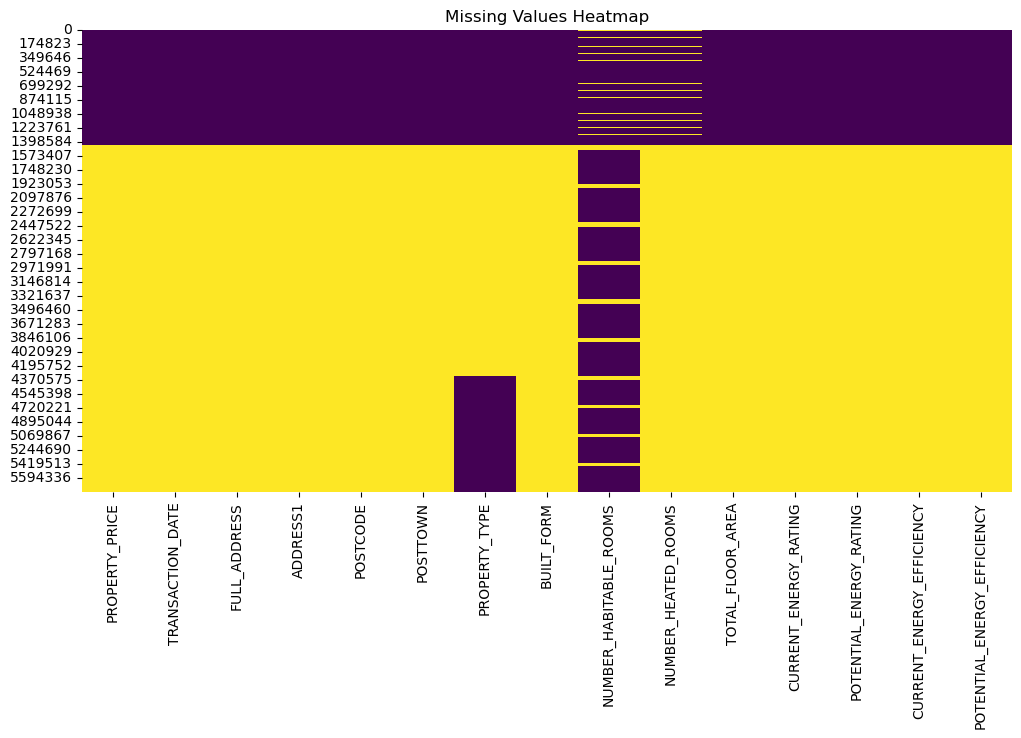

In [19]:
#
# Visual heatmap of missing data
#

# This step will take some time to complete

plt.figure(figsize=(12, 6))
sns.heatmap(df.isnull(), cbar=False, cmap="viridis")
plt.title("Missing Values Heatmap")
plt.show()

In [20]:
#####################################
# Wait here for the heatmap to load #
#####################################

In [21]:
!pip install missingno

In [22]:
import missingno as msno

In [23]:
#
# The next 3 steps will give a high-level view of missingness patterns across the dataset.
#

<Axes: >

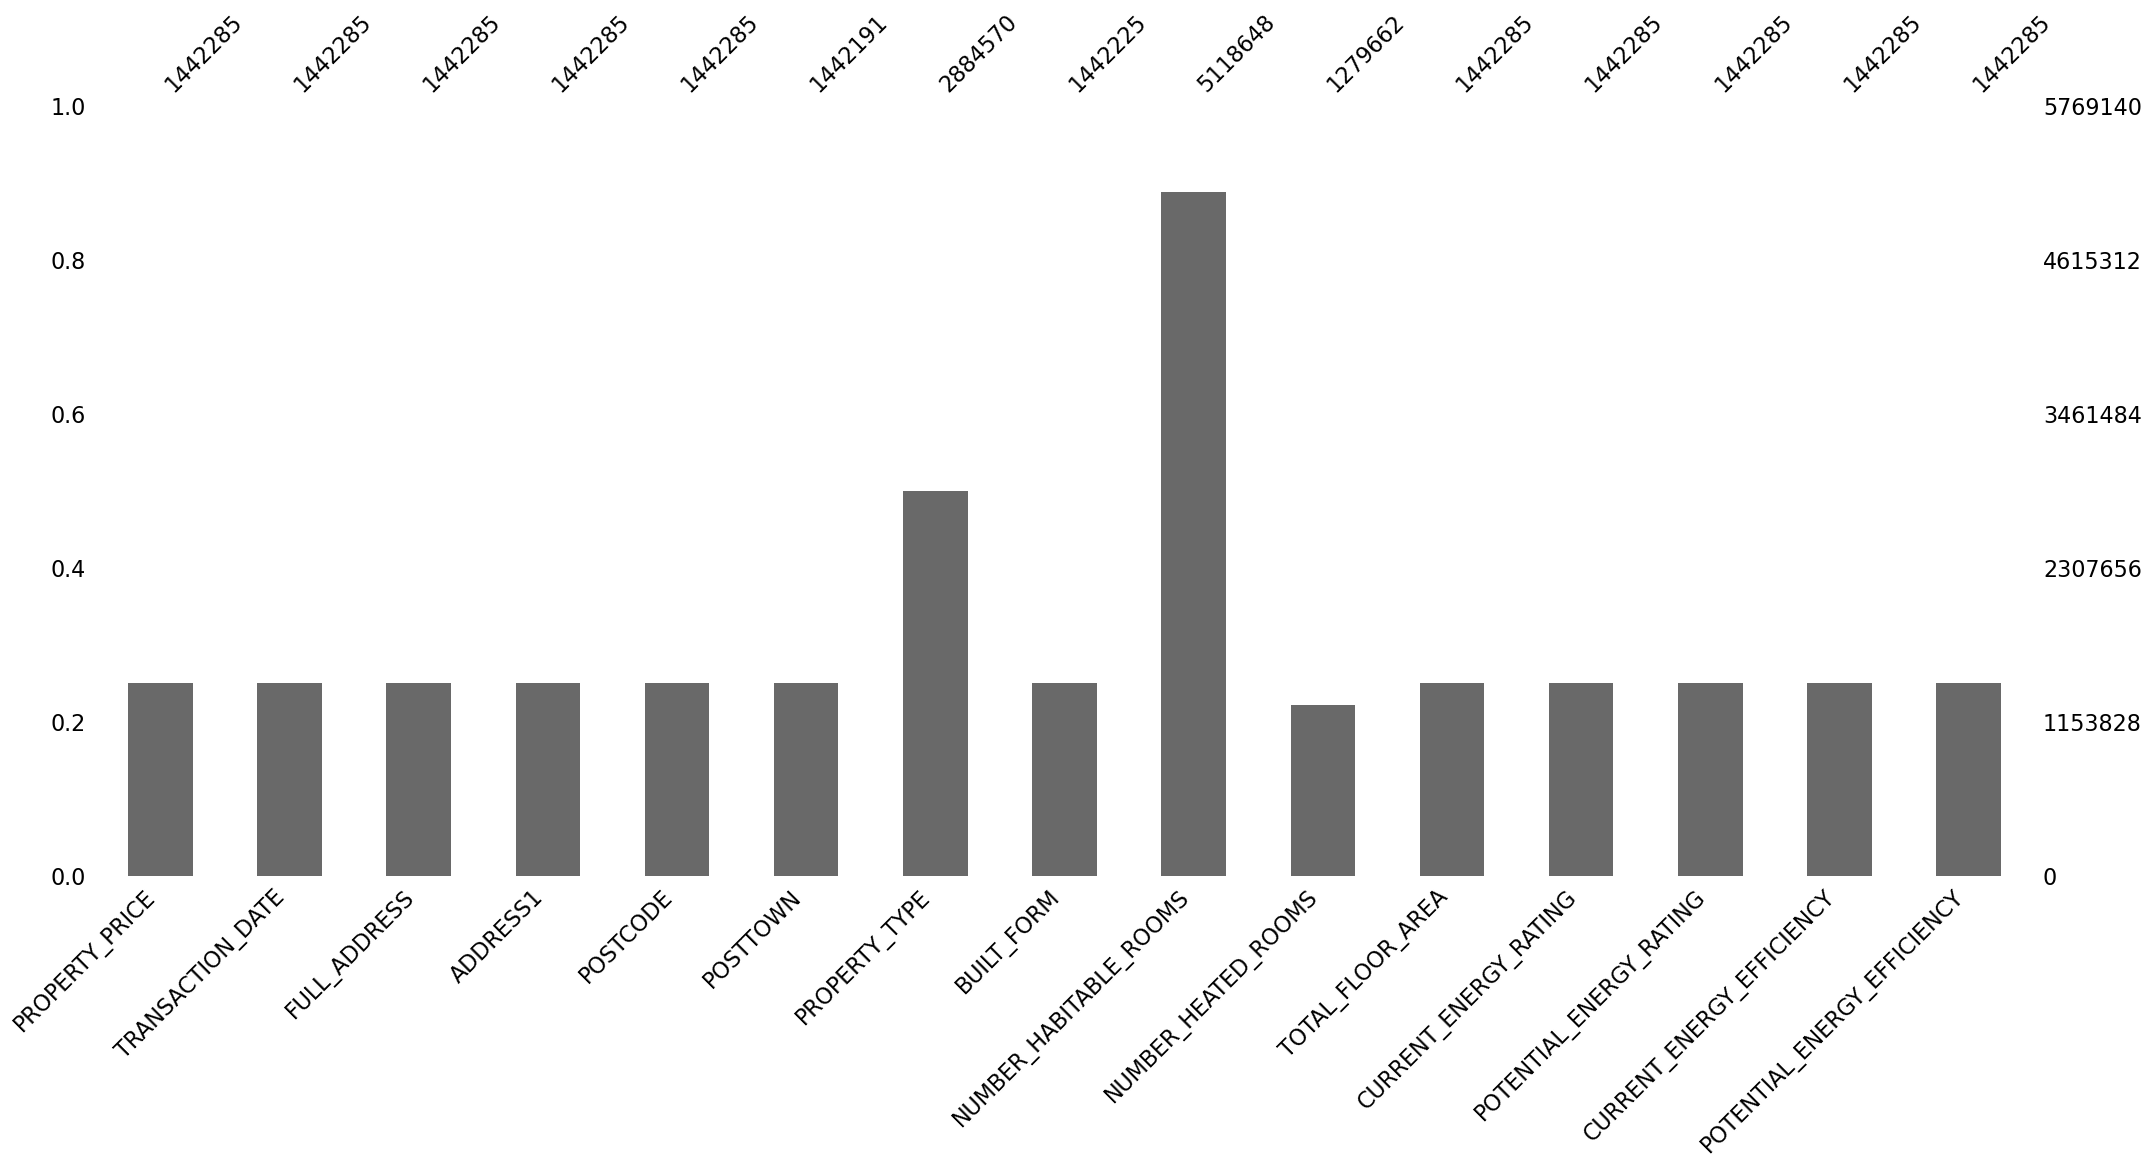

In [24]:
#
# Bar chart of missing values
#

msno.bar(df)

<Axes: >

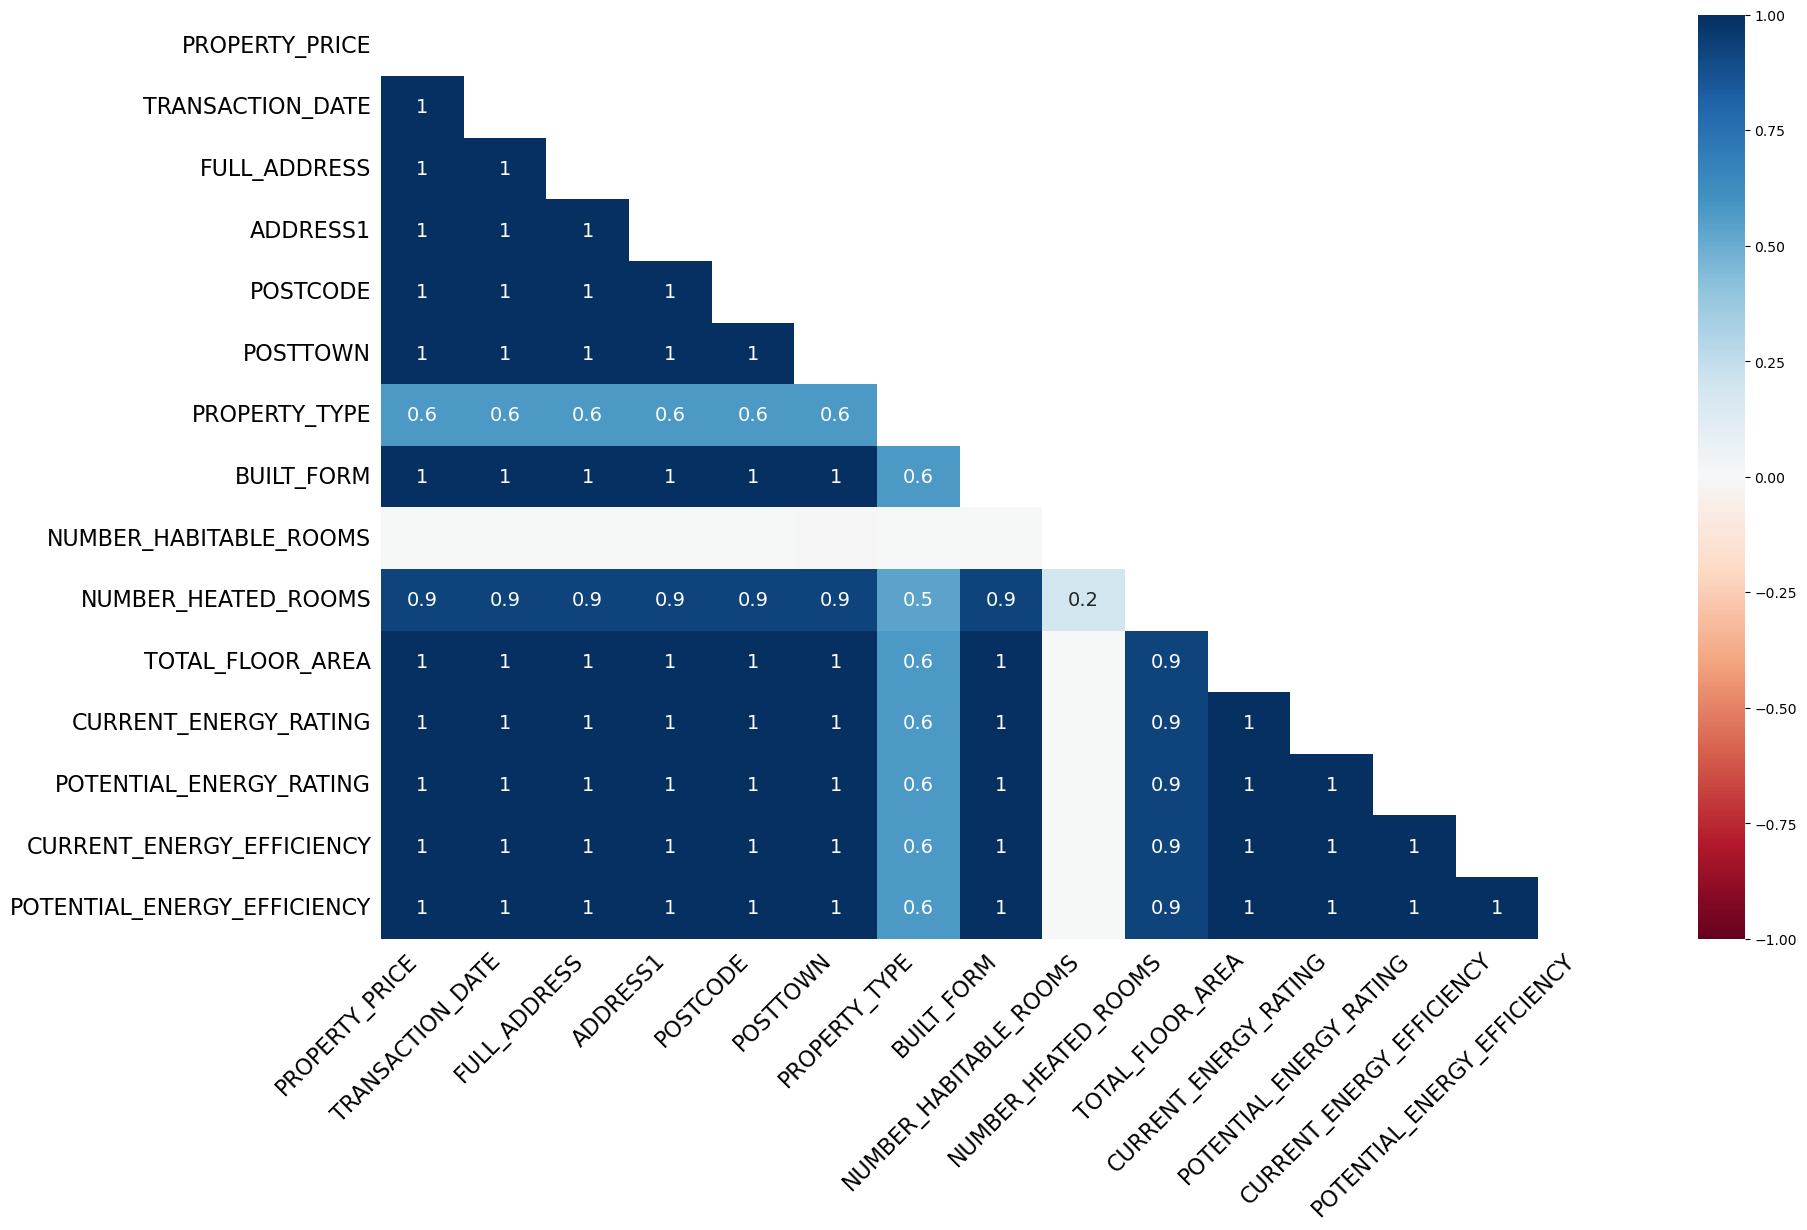

In [25]:
#
# Correlation heatmap of missingness
#

msno.heatmap(df)

<Axes: >

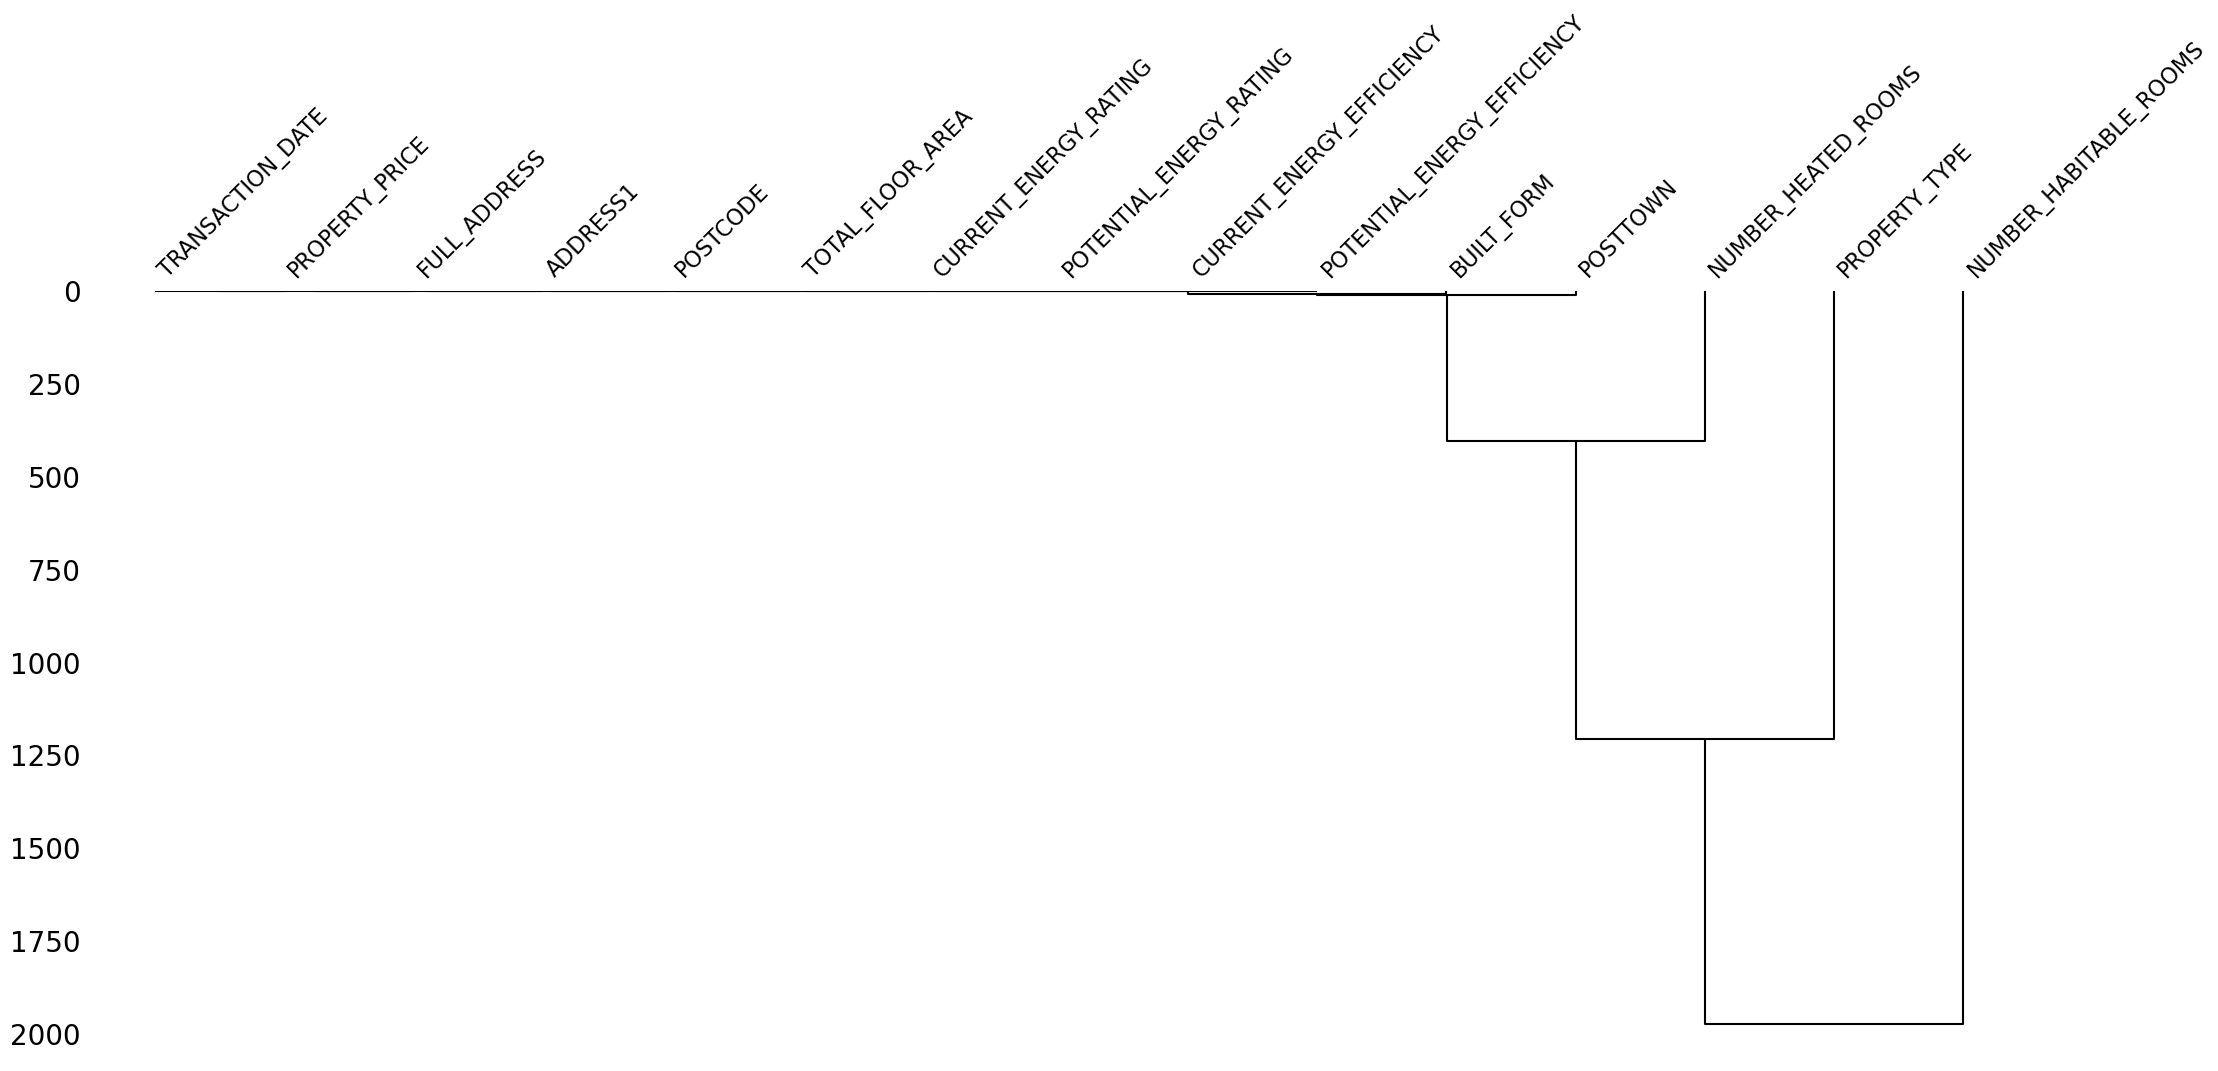

In [26]:
#
# Dendrogram to cluster missingness patterns
#

msno.dendrogram(df)

In [27]:
###########################################################
# Wait here for bar chart, heatmap and dendrogram to load #
###########################################################

In [28]:
# Count rows with missing target value
missing_price_count = df['PROPERTY_PRICE'].isnull().sum()
print(f"Number of rows with missing PROPERTY_PRICE: {missing_price_count}")

Number of rows with missing PROPERTY_PRICE: 4326855


In [29]:
#
# The answer to the question that I posed above is that there are 4326855 rows out of a total 5769140 that do not have a property price
#

In [30]:
missing_date_count = df['TRANSACTION_DATE'].isnull().sum()
print(f"Rows missing TRANSACTION_DATE: {missing_date_count}")

missing_full_address = df['FULL_ADDRESS'].isnull().sum()
print(f"Rows missing FULL_ADDRESS: {missing_full_address}")

missing_address1 = df['ADDRESS1'].isnull().sum()
print(f"Rows missing ADDRESS1: {missing_address1}")

missing_postcode_count = df['POSTCODE'].isnull().sum()
print(f"Rows missing POSTCODE: {missing_postcode_count}")

missing_posttown = df['POSTTOWN'].isnull().sum()
print(f"Rows missing POSTTOWN: {missing_posttown}")

missing_property_type = df['PROPERTY_TYPE'].isnull().sum()
print(f"Rows missing PROPERTY_TYPE: {missing_property_type}")

missing_built_form = df['BUILT_FORM'].isnull().sum()
print(f"Rows missing BUILT_FORM: {missing_built_form}")

missing_habitable_rooms = df['NUMBER_HABITABLE_ROOMS'].isnull().sum()
print(f"Rows missing NUMBER_HABITABLE_ROOMS: {missing_habitable_rooms}")

missing_heated_rooms = df['NUMBER_HEATED_ROOMS'].isnull().sum()
print(f"Rows missing NUMBER_HEATED_ROOMS: {missing_heated_rooms}")

missing_floor_area = df['TOTAL_FLOOR_AREA'].isnull().sum()
print(f"Rows missing TOTAL_FLOOR_AREA: {missing_floor_area}")

missing_current_rating = df['CURRENT_ENERGY_RATING'].isnull().sum()
print(f"Rows missing CURRENT_ENERGY_RATING: {missing_current_rating}")

missing_potential_rating = df['POTENTIAL_ENERGY_RATING'].isnull().sum()
print(f"Rows missing POTENTIAL_ENERGY_RATING: {missing_potential_rating}")

missing_current_efficiency = df['CURRENT_ENERGY_EFFICIENCY'].isnull().sum()
print(f"Rows missing CURRENT_ENERGY_EFFICIENCY: {missing_current_efficiency}")

missing_potential_efficiency = df['POTENTIAL_ENERGY_EFFICIENCY'].isnull().sum()
print(f"Rows missing POTENTIAL_ENERGY_EFFICIENCY: {missing_potential_efficiency}")

Rows missing TRANSACTION_DATE: 4326855
Rows missing FULL_ADDRESS: 4326855
Rows missing ADDRESS1: 4326855
Rows missing POSTCODE: 4326855
Rows missing POSTTOWN: 4326949
Rows missing PROPERTY_TYPE: 2884570
Rows missing BUILT_FORM: 4326915
Rows missing NUMBER_HABITABLE_ROOMS: 650492
Rows missing NUMBER_HEATED_ROOMS: 4489478
Rows missing TOTAL_FLOOR_AREA: 4326855
Rows missing CURRENT_ENERGY_RATING: 4326855
Rows missing POTENTIAL_ENERGY_RATING: 4326855
Rows missing CURRENT_ENERGY_EFFICIENCY: 4326855
Rows missing POTENTIAL_ENERGY_EFFICIENCY: 4326855


In [31]:
#
# The code below deletes all rows with a null property price
#

In [32]:
rows_before = df.shape[0]

In [33]:
df = df.dropna(subset=['PROPERTY_PRICE'])

In [34]:
rows_after = df.shape[0]

In [35]:
print(f"Dropped {rows_before - rows_after} rows with missing PROPERTY_PRICE")

Dropped 4326855 rows with missing PROPERTY_PRICE


In [36]:
#
# This step confirms that there are no rows where the property price is null and that the data is suitable for supervised learning
#

print(f"Missing PROPERTY_PRICE values: {df['PROPERTY_PRICE'].isnull().sum()}")
print(f"Total usable rows: {df.shape[0]}")

Missing PROPERTY_PRICE values: 0
Total usable rows: 1442285


Duplicate rows: 0


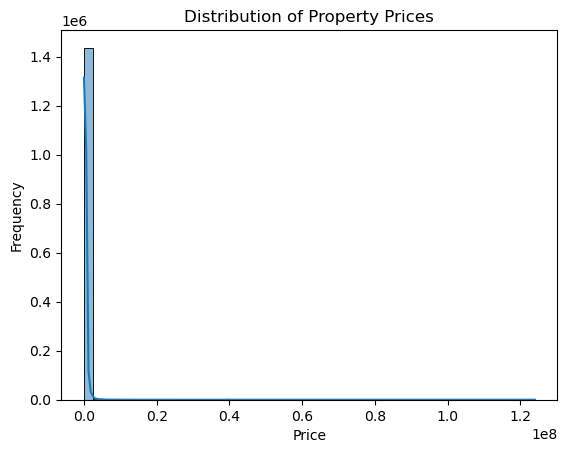

In [37]:
# Check for duplicates
print(f"Duplicate rows: {df.duplicated().sum()}")

# Confirm target distribution
sns.histplot(df['PROPERTY_PRICE'], bins=50, kde=True)
plt.title("Distribution of Property Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

In [38]:
###############################
# Wait here for chart to load #
###############################

In [39]:
#######################################################################
# Predicting house prices is a regression problem in machine learning # 
#######################################################################

In [40]:
#
# Split the dataset into features (X) and target (y)
#

#  X: All columns except PROPERTY_PRICE which is the value we're trying to predict.
# X = df.drop('PROPERTY_PRICE', axis=1)

# y: The target vector, containing the actual PROPERTY_PRICE.
# y = df['PROPERTY_PRICE']

In [41]:
#
# Due to an error when training my first model, I decided to reduce the number of columns and keep the first iteration of model training very simple
#

# Location granularity ('POSTTOWN', 'POSTCODE')
# Structural features ('PROPERTY_TYPE', 'BUILT_FORM')
# Target ('PROPERTY_PRICE')
# Temporal context ('TRANSACTION_DATE')

columns_to_keep = ['PROPERTY_TYPE', 'BUILT_FORM', 'POSTTOWN', 'POSTCODE', 'PROPERTY_PRICE', 'TRANSACTION_DATE']

df = df[columns_to_keep]

desired_order = ['POSTTOWN', 'POSTCODE', 'PROPERTY_TYPE', 'BUILT_FORM', 'PROPERTY_PRICE', 'TRANSACTION_DATE']
df = df[desired_order]

# print(df.head())

print("\nFirst 20 rows:")                                                                    
display(df.head(20))  


First 20 rows:


,POSTTOWN,POSTCODE,PROPERTY_TYPE,BUILT_FORM,PROPERTY_PRICE,TRANSACTION_DATE
0,ST. LEONARDS-ON-SEA,TN38 0GE,House,End-Terrace,280000.0,2011-04-01
1,DARTFORD,DA2 6GY,House,End-Terrace,215000.0,2008-12-12
2,BASINGSTOKE,RG24 9TE,House,Semi-Detached,296500.0,2016-08-10
3,SHREWSBURY,SY1 2RP,House,Mid-Terrace,290000.0,2022-10-01
4,EAST COWES,PO32 6GL,House,Semi-Detached,185995.0,2009-09-07
5,PORTSMOUTH,PO2 9AR,House,Mid-Terrace,257000.0,2018-06-11
6,DUKINFIELD,SK16 4SJ,House,Mid-Terrace,150850.0,2009-05-29
7,HYDE,SK14 4GP,House,Mid-Terrace,204200.0,2008-02-29
8,CARLISLE,CA1 3BF,House,End-Terrace,151950.0,2009-10-09
9,HULL,HU5 1DB,House,Semi-Detached,134400.0,2008-09-05


In [42]:
#
# Define target Liverpool postcode prefixes (L1 to L9 which are close to the city centre and Bootle L20)
#

df_liverpool = df.copy()  

target_prefixes = [f'L{i}' for i in range(1, 9)] + ['L20']

# Extract prefix from POSTCODE (e.g., 'L9' from 'L9 0RW')
df_liverpool['POSTCODE_PREFIX'] = df_liverpool['POSTCODE'].str.extract(r'^(L\d{1,2})')

# Filter rows where prefix is in your target list
df_liverpool = df_liverpool[df_liverpool['POSTCODE_PREFIX'].isin(target_prefixes)]

print("\nFirst 20 rows:")                                                                    
display(df_liverpool.head(20))  


First 20 rows:


,POSTTOWN,POSTCODE,PROPERTY_TYPE,BUILT_FORM,PROPERTY_PRICE,TRANSACTION_DATE,POSTCODE_PREFIX
437,LIVERPOOL,L6 0BY,House,Mid-Terrace,75000.0,2022-04-21,L6
550,LIVERPOOL,L5 3LW,House,End-Terrace,82000.0,2016-04-28,L5
752,LIVERPOOL,L4 8SR,House,Semi-Detached,155000.0,2022-10-07,L4
1498,LIVERPOOL,L4 1AF,House,Mid-Terrace,134000.0,2019-08-23,L4
2761,LIVERPOOL,L8 2YG,Bungalow,Semi-Detached,25750.0,1997-06-27,L8
4530,LIVERPOOL,L6 9AB,House,Semi-Detached,110000.0,2007-03-16,L6
4852,BOOTLE,L20 9ER,House,End-Terrace,125000.0,2022-10-11,L20
6042,LIVERPOOL,L8 1TE,Flat,End-Terrace,120000.0,2020-10-30,L8
6077,LIVERPOOL,L8 1YY,Flat,Mid-Terrace,100000.0,2016-03-18,L8
6671,BOOTLE,L20 4QF,House,Mid-Terrace,55000.0,2022-01-06,L20


In [43]:
#
# The total rows of data after filtering out interested post codes
#

print(f"Total rows in df_liverpool: {df_liverpool.shape[0]}")

Total rows in df_liverpool: 6627


In [44]:
#
# Reorder columns so POSTCODE_PREFIX comes right after POSTCODE
#

cols = df_liverpool.columns.tolist()

cols.insert(cols.index('POSTCODE') + 1, cols.pop(cols.index('POSTCODE_PREFIX')))
df_liverpool = df_liverpool[cols]

print("\nFirst 20 rows:")                                                                    
display(df_liverpool.head(20)) 


First 20 rows:


,POSTTOWN,POSTCODE,POSTCODE_PREFIX,PROPERTY_TYPE,BUILT_FORM,PROPERTY_PRICE,TRANSACTION_DATE
437,LIVERPOOL,L6 0BY,L6,House,Mid-Terrace,75000.0,2022-04-21
550,LIVERPOOL,L5 3LW,L5,House,End-Terrace,82000.0,2016-04-28
752,LIVERPOOL,L4 8SR,L4,House,Semi-Detached,155000.0,2022-10-07
1498,LIVERPOOL,L4 1AF,L4,House,Mid-Terrace,134000.0,2019-08-23
2761,LIVERPOOL,L8 2YG,L8,Bungalow,Semi-Detached,25750.0,1997-06-27
4530,LIVERPOOL,L6 9AB,L6,House,Semi-Detached,110000.0,2007-03-16
4852,BOOTLE,L20 9ER,L20,House,End-Terrace,125000.0,2022-10-11
6042,LIVERPOOL,L8 1TE,L8,Flat,End-Terrace,120000.0,2020-10-30
6077,LIVERPOOL,L8 1YY,L8,Flat,Mid-Terrace,100000.0,2016-03-18
6671,BOOTLE,L20 4QF,L20,House,Mid-Terrace,55000.0,2022-01-06


In [45]:
#
# Breakdown of properties by post code
#

print(df_liverpool['POSTCODE_PREFIX'].value_counts())

POSTCODE_PREFIX
L4     1753
L20    1349
L6     1170
L8      842
L7      691
L5      424
L3      347
L1       48
L2        3
Name: count, dtype: int64


In [46]:
#
# Saving the filtered Liverpool property data to an Excel file for offline inspection
#

df_liverpool.to_excel('liverpool_properties.xlsx', index=False)

In [47]:
# Extracting the the year from the TRANSACTION_DATE column and adds it as a new feature called YEAR 

df_liverpool['YEAR'] = pd.to_datetime(df_liverpool['TRANSACTION_DATE']).dt.year

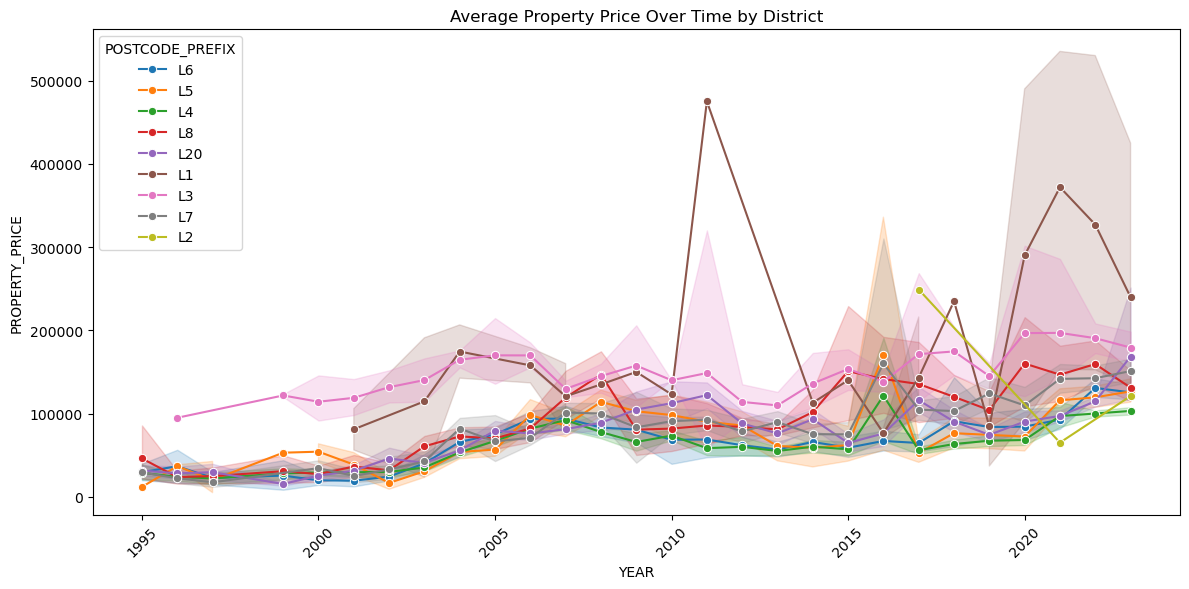

In [48]:
#
# The visualization below will give a view of how property prices have evolved across Liverpool's central districts and Bootle over time. 
# 

plt.figure(figsize=(12,6))
sns.lineplot(data=df_liverpool, x='YEAR', y='PROPERTY_PRICE', hue='POSTCODE_PREFIX', marker='o')
plt.title('Average Property Price Over Time by District')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [49]:
#######################################
# Wait here for visualisation to load #
#######################################

In [50]:
# #####################################
# Preparing data for Machine Learning # 
#######################################

In [51]:
#
# Ensure TRANSACTION_DATE is datetime so that YEAR can be used a numeric feature by my ML model
#

df_liverpool['TRANSACTION_DATE'] = pd.to_datetime(df_liverpool['TRANSACTION_DATE'])

In [52]:
#
# Extract year as a feature into a new column called YEAR
# It transforms a full date (like 2022-04-21) into just the year (2022), which is easier to use as a numerical feature in machine learning models.
#

df_liverpool['YEAR'] = df_liverpool['TRANSACTION_DATE'].dt.year

In [53]:
#
# Confirming the contents of the YEAR column
# That line of code extracts the year from each property's transaction date and stores it in a new column called YEAR
#

print("\nFirst 20 rows:")                                                                    
display(df_liverpool.head(20)) 


First 20 rows:


,POSTTOWN,POSTCODE,POSTCODE_PREFIX,PROPERTY_TYPE,BUILT_FORM,PROPERTY_PRICE,TRANSACTION_DATE,YEAR
437,LIVERPOOL,L6 0BY,L6,House,Mid-Terrace,75000.0,2022-04-21,2022
550,LIVERPOOL,L5 3LW,L5,House,End-Terrace,82000.0,2016-04-28,2016
752,LIVERPOOL,L4 8SR,L4,House,Semi-Detached,155000.0,2022-10-07,2022
1498,LIVERPOOL,L4 1AF,L4,House,Mid-Terrace,134000.0,2019-08-23,2019
2761,LIVERPOOL,L8 2YG,L8,Bungalow,Semi-Detached,25750.0,1997-06-27,1997
4530,LIVERPOOL,L6 9AB,L6,House,Semi-Detached,110000.0,2007-03-16,2007
4852,BOOTLE,L20 9ER,L20,House,End-Terrace,125000.0,2022-10-11,2022
6042,LIVERPOOL,L8 1TE,L8,Flat,End-Terrace,120000.0,2020-10-30,2020
6077,LIVERPOOL,L8 1YY,L8,Flat,Mid-Terrace,100000.0,2016-03-18,2016
6671,BOOTLE,L20 4QF,L20,House,Mid-Terrace,55000.0,2022-01-06,2022


In [54]:
#####################
# Feature selection #
#####################

In [55]:
#
# Define features 
#

# These are the columns that I am going to use as predictors—the inputs to my model. Each one represents a factor that might influence property price:

# Categorical 
# POSTCODE_PREFIX	: District location (e.g., L4, L6)
# PROPERTY_TYPE : House, flat, bungalow, etc.
# BUILT_FORM : Detached, semi-detached, terrace, etc.

# Numerical
# YEAR : Year of transaction, which captures time-based trends

features = ['POSTCODE_PREFIX', 'PROPERTY_TYPE', 'BUILT_FORM', 'YEAR']

In [56]:
#
# Defining PROPERTY_PRICE as the target output that I want predict
#

target = 'PROPERTY_PRICE'

In [57]:
#
# This creates the feature matrix—the input variables that my model will learn from.
#

X = df_liverpool[features]

In [58]:
# This creates the target vector—the output that my model is trying to predict.

y = df_liverpool[target]

In [59]:
# 
# Purpose: Splits the Liverpool dataset into training and testing subsets.
#

from sklearn.model_selection import train_test_split

# X : Feature matrix (See above)
# y : Traget variable (See above)
# test_size : Reserves 20% of the data for testing, 80% for training.
# random_state : Ensures reproducibility — same split every time you run it.

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [60]:
#
# Verifies that both training and test sets have the same feature columns and helps to avoid encoding mismatches or missing columns.
#

print(X_train.columns)
print(X_test.columns)

Index(['POSTCODE_PREFIX', 'PROPERTY_TYPE', 'BUILT_FORM', 'YEAR'], dtype='object')
Index(['POSTCODE_PREFIX', 'PROPERTY_TYPE', 'BUILT_FORM', 'YEAR'], dtype='object')


In [61]:
# Encoding Categorical features AFTER the train-test split.
# If the encoding was performed before splitting:
# There would be a risk data leakage: the encoder sees all categories, including ones that only exist in the test set.
# The model might overfit to rare categories that won’t appear in real-world data.
# The ability to simulate how your pipeline handles unseen categories would be lost.

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

# Identifying which columns contain categorical data—text labels that need to be converted into numbers before modeling.
categorical_features = ['POSTCODE_PREFIX', 'PROPERTY_TYPE', 'BUILT_FORM']

# One-hot encoder
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first'), categorical_features)
    ],
    remainder='passthrough'  # Keep YEAR as-is
)

In [62]:
#
# There are a few models that can be used for predicting house prices in Liverpool. I will start with Linear Regression.
#
# Linear Regression is good for Interpretability, Baselning performance and the spped of training and testing thee model
#

In [63]:
#
# Sets up a machine learning pipeline using linear regression as the model.
#

# Imports the Linear Regression model from scikit-learn
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline

# This creates a pipeline, which is a clean way to chain together multiple steps—like preprocessing and modeling—into one unified object.
# This step applies your ColumnTransformer, which one-hot encodes categorical features and passes through numeric ones like YEAR.
# This step fits a linear regression model to the transformed data.

model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

In [64]:
###################
# Train the model #
###################

model_pipeline.fit(X_train, y_train)

C:\Users\salma\anaconda3\Lib\site-packages\sklearn\compose\_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  OneHotEncoder(drop='first'),
                                                  ['POSTCODE_PREFIX',
                                                   'PROPERTY_TYPE',
                                                   'BUILT_FORM'])])),
                ('regressor', LinearRegression())])

In [65]:
####################
# Make predictions #
####################

y_pred = model_pipeline.predict(X_test)

In [66]:
######################
# Evaluate the model #
######################

In [67]:
#
# Evaluating my models performance using Root Mean Squared Error (RMSE)
# 

# Why RMSE Matters
# Penalizes large errors more than small ones.
# Gives a direct sense of how far off your predictions are, on average.
# Easier to interpret than MSE because it’s in the same unit as .
    
from sklearn.metrics import mean_squared_error
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print(f"RMSE: {rmse:,.2f}")

RMSE: 128,878.44


In [68]:
#
# Evaluating my models performance using R²
# 

# Why R² Is Useful
# Tells you how much of the variation in  is explained by your features.
# Complements RMSE by giving a relative performance measure.
# Helps compare models — especially linear vs tree-based — on interpretability vs accuracy.

from sklearn.metrics import r2_score
r2 = r2_score(y_test, y_pred)
print(f"R² Score: {r2:.4f}")

R² Score: 0.0719


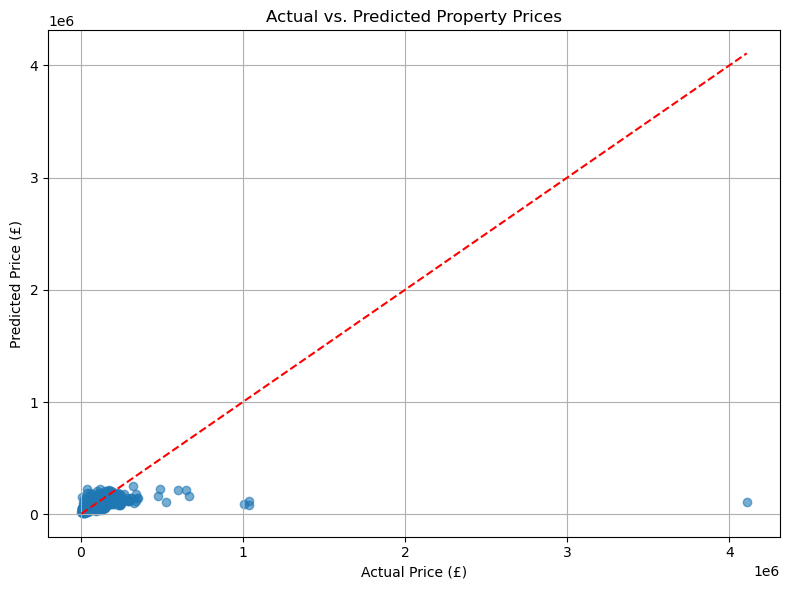

In [69]:
# This shows how close your predictions are to the true prices:

# Points close to the red dashed line = good predictions
# Wide scatter = model struggling to generalize

import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  # perfect prediction line
plt.xlabel('Actual Price (£)')
plt.ylabel('Predicted Price (£)')
plt.title('Actual vs. Predicted Property Prices')
plt.grid(True)
plt.tight_layout()
plt.show()

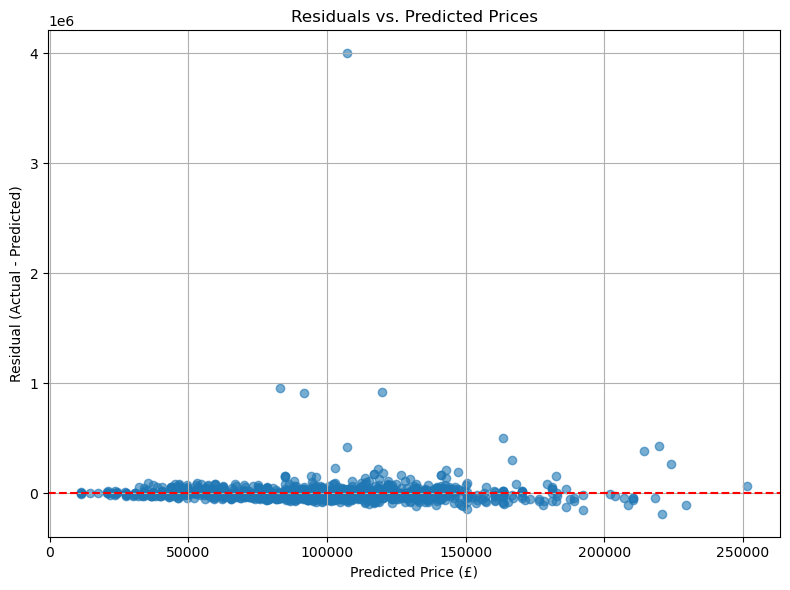

In [70]:
# This shows the difference between predicted and actual prices:

# Random scatter around zero = good model behavior
# Patterns or curves = model missing something (e.g., nonlinearity, missing features)

residuals = y_test - y_pred

plt.figure(figsize=(8,6))
plt.scatter(y_pred, residuals, alpha=0.6)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicted Price (£)')
plt.ylabel('Residual (Actual - Predicted)')
plt.title('Residuals vs. Predicted Prices')
plt.grid(True)
plt.tight_layout()
plt.show()

In [71]:
############################################################################################################################################
# Next steps:                                                                                                                              #
#                                                                                                                                          #
# Try different models (i.e. RandomForestRegressor, GradientBoostingRegressor or XGBoost and compare the results                           #
#                                                                                                                                          # 
# Add More Features i.e. square footage, number of bedrooms, extract month or season from TRANSACTION_DATE as house prices can be seasonal # 

In [72]:
#######################
# Using Random Forest # 
#######################

from sklearn.ensemble import RandomForestRegressor

In [73]:
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1))
])

In [74]:
model_pipeline.fit(X_train, y_train)
y_pred = model_pipeline.predict(X_test)

In [75]:
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5  # or use np.sqrt(mse) if NumPy is imported
print(f"RMSE: {rmse:,.2f}")

RMSE: 127,938.88


In [76]:
r2 = r2_score(y_test, y_pred)

print(f"R² Score: {r2:.4f}")

R² Score: 0.0854


In [77]:
#############################################
# Hyper Parameter Tuning using GridSearchCV # 
#############################################

In [78]:
from sklearn.model_selection import GridSearchCV

# Define the Hyperparameter Grid

param_grid = {
    'regressor__n_estimators': [100, 300, 500],
    'regressor__max_depth': [10, 20, None],
    'regressor__max_features': ['sqrt', 'log2']
}

grid_search = GridSearchCV(model_pipeline, param_grid, cv=5, scoring='neg_root_mean_squared_error', n_jobs=-1)
grid_search.fit(X_train, y_train)

C:\Users\salma\anaconda3\Lib\site-packages\sklearn\compose\_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(remainder='passthrough',
                                                          transformers=[('cat',
                                                                         OneHotEncoder(drop='first'),
                                                                         ['POSTCODE_PREFIX',
                                                                          'PROPERTY_TYPE',
                                                                          'BUILT_FORM'])])),
                                       ('regressor',
                                        RandomForestRegressor(n_jobs=-1,
                                                              random_state=42))]),
             n_jobs=-1,
             param_grid={'regressor__max_depth': [10, 20, None],
                         'regressor__max_features': ['sqrt', 'log2'],
                         'regressor__n_estimators': [100, 300, 500]},
             scoring='neg_root_mean_squared_error')

In [79]:
print("Best RMSE:", -grid_search.best_score_)
print("Best Parameters:", grid_search.best_params_)

Best RMSE: 83719.78595194008
Best Parameters: {'regressor__max_depth': 10, 'regressor__max_features': 'sqrt', 'regressor__n_estimators': 500}


In [80]:
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

from sklearn.metrics import r2_score
r2 = r2_score(y_test, y_pred)
print(f"R² Score: {r2:.4f}")

R² Score: 0.0979


In [81]:
##################################
# Wait for results to be printed # 
##################################

In [82]:
#
# Evaluation on a test set
#

best_model = grid_search.best_estimator_
y_best_pred = best_model.predict(X_test)

from sklearn.metrics import mean_squared_error, r2_score
rmse_best = np.sqrt(mean_squared_error(y_test, y_best_pred))
r2_best = r2_score(y_test, y_best_pred)

print(f"Test RMSE: £{rmse_best:,.2f}")
print(f"Test R² Score: {r2_best:.4f}")

Test RMSE: £127,063.09
Test R² Score: 0.0979


In [83]:
##################################
# Wait for results to be printed # 
##################################

In [84]:
###########################
# Using Gradient Boosting #
###########################

from sklearn.ensemble import GradientBoostingRegressor

In [85]:
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', GradientBoostingRegressor(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=3,
        random_state=42
    ))
])

In [86]:
model_pipeline.fit(X_train, y_train)
y_pred = model_pipeline.predict(X_test)

In [87]:
rmse = mean_squared_error(y_test, y_pred) ** 0.5
print(f"RMSE: {rmse:,.2f}")

RMSE: 127,595.82


In [88]:
r2 = r2_score(y_test, y_pred)
print(f"R² Score: {r2:.4f}")

R² Score: 0.0903


In [89]:
##################################
# Wait for results to be printed # 
##################################

In [90]:
#############################################
# Hyper Parameter Tuning using GridSearchCV # 
#############################################

In [91]:
# Define the Hyperparameter Grid

param_grid = {
    'regressor__n_estimators': [100, 300, 500],
    'regressor__learning_rate': [0.01, 0.1, 0.3],
    'regressor__max_depth': [3, 5, 7]
}

grid_search = GridSearchCV(
    model_pipeline,
    param_grid,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

C:\Users\salma\anaconda3\Lib\site-packages\sklearn\compose\_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(remainder='passthrough',
                                                          transformers=[('cat',
                                                                         OneHotEncoder(drop='first'),
                                                                         ['POSTCODE_PREFIX',
                                                                          'PROPERTY_TYPE',
                                                                          'BUILT_FORM'])])),
                                       ('regressor',
                                        GradientBoostingRegressor(random_state=42))]),
             n_jobs=-1,
             param_grid={'regressor__learning_rate': [0.01, 0.1, 0.3],
                         'regressor__max_depth': [3, 5, 7],
                         'regressor__n_estimators': [100, 300, 500]},
             scoring='neg_root_mean_squared_error')

In [92]:
print("Best RMSE:", -grid_search.best_score_)
print("Best Parameters:", grid_search.best_params_)

Best RMSE: 84021.15667932897
Best Parameters: {'regressor__learning_rate': 0.01, 'regressor__max_depth': 3, 'regressor__n_estimators': 500}


In [93]:
r2 = r2_score(y_test, y_pred)
print(f"R² Score: {r2:.4f}")

R² Score: 0.0903


In [94]:
#
# Evaluation on a test set
#

best_model = grid_search.best_estimator_
y_best_pred = best_model.predict(X_test)

rmse_test = np.sqrt(mean_squared_error(y_test, y_best_pred))
r2_test = r2_score(y_test, y_best_pred)

print(f"Test RMSE: £{rmse_test:,.2f}")
print(f"Test R² Score: {r2_test:.4f}")

Test RMSE: £128,157.32
Test R² Score: 0.0823


In [95]:
##################################
# Wait for results to be printed # 
##################################

In [96]:
##################
# Trying XGBoost # 
##################

In [97]:
!pip install xgboost

In [98]:
from xgboost import XGBRegressor

model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', XGBRegressor(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=6,
        random_state=42,
        n_jobs=-1
    ))
])

In [99]:
model_pipeline.fit(X_train, y_train)
y_pred = model_pipeline.predict(X_test)

In [100]:
rmse = mean_squared_error(y_test, y_pred) ** 0.5
print(f"XGBoost RMSE: {rmse:,.2f}")

XGBoost RMSE: 127,191.05


In [101]:
r2 = r2_score(y_test, y_pred)
print(f"XGBoost R² Score: {r2:.4f}")

XGBoost R² Score: 0.0961


In [102]:
##################################
# Wait for results to be printed # 
##################################

In [103]:
#############################################
# Hyper Parameter Tuning using GridSearchCV # 
#############################################

In [104]:
# Define the Hyperparameter Grid

param_grid = {
    'regressor__n_estimators': [100, 300, 500],
    'regressor__learning_rate': [0.01, 0.1, 0.3],
    'regressor__max_depth': [3, 5, 7],
    'regressor__colsample_bytree': [0.6, 0.8, 1.0],
    'regressor__subsample': [0.6, 0.8, 1.0]
}

grid_search = GridSearchCV(
    model_pipeline,
    param_grid,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

C:\Users\salma\anaconda3\Lib\site-packages\sklearn\compose\_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(remainder='passthrough',
                                                          transformers=[('cat',
                                                                         OneHotEncoder(drop='first'),
                                                                         ['POSTCODE_PREFIX',
                                                                          'PROPERTY_TYPE',
                                                                          'BUILT_FORM'])])),
                                       ('regressor',
                                        XGBRegressor(base_score=None,
                                                     booster=None,
                                                     callbacks=None,
                                                     colsample_bylevel=None,
                                                     colsample_bynode=None,
                                                     colsample_bytree=None,
                                                     device=No...
                                                     monotone_constraints=None,
                                                     multi_strategy=None,
                                                     n_estimators=100,
                                                     n_jobs=-1,
                                                     num_parallel_tree=None, ...))]),
             n_jobs=-1,
             param_grid={'regressor__colsample_bytree': [0.6, 0.8, 1.0],
                         'regressor__learning_rate': [0.01, 0.1, 0.3],
                         'regressor__max_depth': [3, 5, 7],
                         'regressor__n_estimators': [100, 300, 500],
                         'regressor__subsample': [0.6, 0.8, 1.0]},
             scoring='neg_root_mean_squared_error')

In [105]:
print("Best RMSE:", -grid_search.best_score_)
print("Best Parameters:", grid_search.best_params_)

Best RMSE: 83459.30095304709
Best Parameters: {'regressor__colsample_bytree': 0.6, 'regressor__learning_rate': 0.1, 'regressor__max_depth': 3, 'regressor__n_estimators': 100, 'regressor__subsample': 0.6}


In [106]:
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

r2 = r2_score(y_test, y_pred)
print(f"R² Score: {r2:.4f}")

R² Score: 0.0867


In [107]:
##################################
# Wait for results to be printed # 
##################################

In [109]:
###########################################################
# Adding another input parameter (NUMBER_HABITABLE_ROOMS) #
###########################################################

In [110]:
# Location granularity ('POSTTOWN', 'POSTCODE')
# Structural features ('PROPERTY_TYPE', 'BUILT_FORM')
# Target ('PROPERTY_PRICE')
# Temporal context ('TRANSACTION_DATE')

df = pd.read_csv("merged_master_with_price_data.csv", on_bad_lines='skip', low_memory=False)

columns_to_keep = ['PROPERTY_TYPE', 'BUILT_FORM', 'NUMBER_HABITABLE_ROOMS', 'POSTTOWN', 'POSTCODE', 'PROPERTY_PRICE', 'TRANSACTION_DATE']

df = df[columns_to_keep]

desired_order = ['POSTTOWN', 'POSTCODE', 'PROPERTY_TYPE', 'BUILT_FORM', 'NUMBER_HABITABLE_ROOMS', 'PROPERTY_PRICE', 'TRANSACTION_DATE']
df = df[desired_order]

# print(df.head())

In [111]:
#
# Define target Liverpool postcode prefixes (L1 to L9 which are close to the city centre and Bootle L20)
#

df_liverpool = df.copy()  

target_prefixes = [f'L{i}' for i in range(1, 9)] + ['L20']

# Extract prefix from POSTCODE (e.g., 'L9' from 'L9 0RW')
df_liverpool['POSTCODE_PREFIX'] = df_liverpool['POSTCODE'].str.extract(r'^(L\d{1,2})')

# Filter rows where prefix is in your target list
df_liverpool = df_liverpool[df_liverpool['POSTCODE_PREFIX'].isin(target_prefixes)]

print("\nFirst 20 rows:")                                                                    
display(df_liverpool.head(20))  


First 20 rows:


,POSTTOWN,POSTCODE,PROPERTY_TYPE,BUILT_FORM,NUMBER_HABITABLE_ROOMS,PROPERTY_PRICE,TRANSACTION_DATE,POSTCODE_PREFIX
437,LIVERPOOL,L6 0BY,House,Mid-Terrace,4.0,75000.0,2022-04-21,L6
550,LIVERPOOL,L5 3LW,House,End-Terrace,5.0,82000.0,2016-04-28,L5
752,LIVERPOOL,L4 8SR,House,Semi-Detached,5.0,155000.0,2022-10-07,L4
1498,LIVERPOOL,L4 1AF,House,Mid-Terrace,5.0,134000.0,2019-08-23,L4
2761,LIVERPOOL,L8 2YG,Bungalow,Semi-Detached,3.0,25750.0,1997-06-27,L8
4530,LIVERPOOL,L6 9AB,House,Semi-Detached,6.0,110000.0,2007-03-16,L6
4852,BOOTLE,L20 9ER,House,End-Terrace,4.0,125000.0,2022-10-11,L20
6042,LIVERPOOL,L8 1TE,Flat,End-Terrace,3.0,120000.0,2020-10-30,L8
6077,LIVERPOOL,L8 1YY,Flat,Mid-Terrace,3.0,100000.0,2016-03-18,L8
6671,BOOTLE,L20 4QF,House,Mid-Terrace,4.0,55000.0,2022-01-06,L20


In [112]:
#
# Reorder columns so POSTCODE_PREFIX comes right after POSTCODE
#

cols = df_liverpool.columns.tolist()

cols.insert(cols.index('POSTCODE') + 1, cols.pop(cols.index('POSTCODE_PREFIX')))
df_liverpool = df_liverpool[cols]

print("\nFirst 20 rows:")                                                                    
display(df_liverpool.head(20)) 


First 20 rows:


,POSTTOWN,POSTCODE,POSTCODE_PREFIX,PROPERTY_TYPE,BUILT_FORM,NUMBER_HABITABLE_ROOMS,PROPERTY_PRICE,TRANSACTION_DATE
437,LIVERPOOL,L6 0BY,L6,House,Mid-Terrace,4.0,75000.0,2022-04-21
550,LIVERPOOL,L5 3LW,L5,House,End-Terrace,5.0,82000.0,2016-04-28
752,LIVERPOOL,L4 8SR,L4,House,Semi-Detached,5.0,155000.0,2022-10-07
1498,LIVERPOOL,L4 1AF,L4,House,Mid-Terrace,5.0,134000.0,2019-08-23
2761,LIVERPOOL,L8 2YG,L8,Bungalow,Semi-Detached,3.0,25750.0,1997-06-27
4530,LIVERPOOL,L6 9AB,L6,House,Semi-Detached,6.0,110000.0,2007-03-16
4852,BOOTLE,L20 9ER,L20,House,End-Terrace,4.0,125000.0,2022-10-11
6042,LIVERPOOL,L8 1TE,L8,Flat,End-Terrace,3.0,120000.0,2020-10-30
6077,LIVERPOOL,L8 1YY,L8,Flat,Mid-Terrace,3.0,100000.0,2016-03-18
6671,BOOTLE,L20 4QF,L20,House,Mid-Terrace,4.0,55000.0,2022-01-06


In [113]:
##################################
# Wait for results to be printed # 
##################################

In [114]:
#
# Ensure TRANSACTION_DATE is datetime so that YEAR can be used a numeric feature by my ML model
#

df_liverpool['TRANSACTION_DATE'] = pd.to_datetime(df_liverpool['TRANSACTION_DATE'])

In [115]:
#
# Extract year as a feature into a new column called YEAR
# It transforms a full date (like 2022-04-21) into just the year (2022), which is easier to use as a numerical feature in machine learning models.
#

df_liverpool['YEAR'] = df_liverpool['TRANSACTION_DATE'].dt.year

In [116]:
#
# Confirming the contents of the YEAR column
# That line of code extracts the year from each property's transaction date and stores it in a new column called YEAR
#

print("\nFirst 20 rows:")                                                                    
display(df_liverpool.head(20)) 


First 20 rows:


,POSTTOWN,POSTCODE,POSTCODE_PREFIX,PROPERTY_TYPE,BUILT_FORM,NUMBER_HABITABLE_ROOMS,PROPERTY_PRICE,TRANSACTION_DATE,YEAR
437,LIVERPOOL,L6 0BY,L6,House,Mid-Terrace,4.0,75000.0,2022-04-21,2022
550,LIVERPOOL,L5 3LW,L5,House,End-Terrace,5.0,82000.0,2016-04-28,2016
752,LIVERPOOL,L4 8SR,L4,House,Semi-Detached,5.0,155000.0,2022-10-07,2022
1498,LIVERPOOL,L4 1AF,L4,House,Mid-Terrace,5.0,134000.0,2019-08-23,2019
2761,LIVERPOOL,L8 2YG,L8,Bungalow,Semi-Detached,3.0,25750.0,1997-06-27,1997
4530,LIVERPOOL,L6 9AB,L6,House,Semi-Detached,6.0,110000.0,2007-03-16,2007
4852,BOOTLE,L20 9ER,L20,House,End-Terrace,4.0,125000.0,2022-10-11,2022
6042,LIVERPOOL,L8 1TE,L8,Flat,End-Terrace,3.0,120000.0,2020-10-30,2020
6077,LIVERPOOL,L8 1YY,L8,Flat,Mid-Terrace,3.0,100000.0,2016-03-18,2016
6671,BOOTLE,L20 4QF,L20,House,Mid-Terrace,4.0,55000.0,2022-01-06,2022


In [117]:
#
# Define features 
#

# These are the columns that I am going to use as predictors—the inputs to my model. Each one represents a factor that might influence property price:

# Categorical 
# POSTCODE_PREFIX	: District location (e.g., L4, L6)
# PROPERTY_TYPE : House, flat, bungalow, etc.
# BUILT_FORM : Detached, semi-detached, terrace, etc.

# Numerical
# YEAR : Year of transaction, which captures time-based trends

features = ['POSTCODE_PREFIX', 'PROPERTY_TYPE', 'BUILT_FORM', 'NUMBER_HABITABLE_ROOMS', 'YEAR']

In [118]:
#
# Defining PROPERTY_PRICE as the target output that I want predict
#

target = 'PROPERTY_PRICE'

In [119]:
#
# This creates the feature matrix—the input variables that my model will learn from.
#

X = df_liverpool[features]

In [120]:
# This creates the target vector—the output that my model is trying to predict.

y = df_liverpool[target]

In [121]:
# 
# Purpose: Splits the Liverpool dataset into training and testing subsets.
#

from sklearn.model_selection import train_test_split

# X : Feature matrix (See above)
# y : Traget variable (See above)
# test_size : Reserves 20% of the data for testing, 80% for training.
# random_state : Ensures reproducibility — same split every time you run it.

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [122]:
# Encoding Categorical features AFTER the train-test split.
# If the encoding was performed before splitting:
# There would be a risk data leakage: the encoder sees all categories, including ones that only exist in the test set.
# The model might overfit to rare categories that won’t appear in real-world data.
# The ability to simulate how your pipeline handles unseen categories would be lost.

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

# Identifying which columns contain categorical data—text labels that need to be converted into numbers before modeling.
categorical_features = ['POSTCODE_PREFIX', 'PROPERTY_TYPE', 'BUILT_FORM']

# One-hot encoder
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first'), categorical_features)
    ],
    remainder='passthrough'  # Keep YEAR as-is
)

In [123]:
from xgboost import XGBRegressor

model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', XGBRegressor(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=6,
        random_state=42,
        n_jobs=-1
    ))
])

In [124]:
model_pipeline.fit(X_train, y_train)
y_pred = model_pipeline.predict(X_test)

In [125]:
rmse = mean_squared_error(y_test, y_pred) ** 0.5
print(f"XGBoost RMSE: {rmse:,.2f}")

XGBoost RMSE: 125,838.69


In [126]:
r2 = r2_score(y_test, y_pred)
print(f"XGBoost R² Score: {r2:.4f}")

XGBoost R² Score: 0.1152


In [127]:
##################################
# Wait for results to be printed # 
##################################

In [128]:
# Define the Hyperparameter Grid

param_grid = {
    'regressor__n_estimators': [100, 300, 500],
    'regressor__learning_rate': [0.01, 0.1, 0.3],
    'regressor__max_depth': [3, 5, 7],
    'regressor__colsample_bytree': [0.6, 0.8, 1.0],
    'regressor__subsample': [0.6, 0.8, 1.0]
}

grid_search = GridSearchCV(
    model_pipeline,
    param_grid,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

C:\Users\salma\anaconda3\Lib\site-packages\sklearn\compose\_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(remainder='passthrough',
                                                          transformers=[('cat',
                                                                         OneHotEncoder(drop='first'),
                                                                         ['POSTCODE_PREFIX',
                                                                          'PROPERTY_TYPE',
                                                                          'BUILT_FORM'])])),
                                       ('regressor',
                                        XGBRegressor(base_score=None,
                                                     booster=None,
                                                     callbacks=None,
                                                     colsample_bylevel=None,
                                                     colsample_bynode=None,
                                                     colsample_bytree=None,
                                                     device=No...
                                                     monotone_constraints=None,
                                                     multi_strategy=None,
                                                     n_estimators=100,
                                                     n_jobs=-1,
                                                     num_parallel_tree=None, ...))]),
             n_jobs=-1,
             param_grid={'regressor__colsample_bytree': [0.6, 0.8, 1.0],
                         'regressor__learning_rate': [0.01, 0.1, 0.3],
                         'regressor__max_depth': [3, 5, 7],
                         'regressor__n_estimators': [100, 300, 500],
                         'regressor__subsample': [0.6, 0.8, 1.0]},
             scoring='neg_root_mean_squared_error')

In [129]:
print("Best RMSE:", -grid_search.best_score_)
print("Best Parameters:", grid_search.best_params_)

Best RMSE: 77346.52540297412
Best Parameters: {'regressor__colsample_bytree': 0.6, 'regressor__learning_rate': 0.1, 'regressor__max_depth': 3, 'regressor__n_estimators': 100, 'regressor__subsample': 0.8}


In [130]:
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

r2 = r2_score(y_test, y_pred)
print(f"R² Score: {r2:.4f}")

R² Score: 0.1220


In [156]:
##################################
# Wait for results to be printed # 
##################################

In [ ]:
################################################
# End of Project - Please refer to readme file #
################################################